In [1]:
import os
import pickle

### Settings

In [2]:
DIR_DATA = "data"
DIR_TEXTS = os.path.join(DIR_DATA, "texts")
FILE_METADATA = os.path.join(DIR_DATA, "metadata.csv")

cleaned_corpus_indices_path = os.path.join(DIR_DATA, "cleaned_corpus_indices.pkl")
cleaned_corpus_token_to_index_path = os.path.join(DIR_DATA, "token_to_index.pkl")
cleaned_corpus_index_to_token_path = os.path.join(DIR_DATA, "index_to_token.pkl")

# Generate up to n-grams (2, ..., MAX_N)
MAX_N = 5

In [3]:
# Load the cleaned corpus indices and the index-to-token mapping
with open(cleaned_corpus_indices_path, "rb") as f:
    tokens = pickle.load(f)
    
with open(cleaned_corpus_index_to_token_path, "rb") as f:
    index_to_token = pickle.load(f)
    
print(f"Loaded {len(tokens)} tokens and {len(index_to_token)} unique tokens.")

Loaded 12243964 tokens and 25106 unique tokens.


### Bi-gram

In [4]:
PROGRESS_RESOLUTION = 50000
PROGRESS_BAR_WIDTH = 50

def get_ngram_counts(input_tokens: list[int], max_n: int) -> dict[int, dict[int, any]]:

    # Allows us to safely start the loop at 1
    assert max_n >= 2, "n-grams only make sense for n >= 2"
    ns = list(range(2, max_n + 1))
    
    # Big dictionary of dictionaries
    # The first key is the n in n-gram,
    # The other keys are the sequences of tokens
    ngram_counts: dict[int, dict[tuple[int, ...], dict[int, int]]] = {
        n: {} for n in ns
    }
    
    # Iterate through each token in the corpus (skip first n-1 tokens)
    for token_i in range(1, len(input_tokens)):
        
        # Print progress every PROGRESS_RESOLUTION tokens
        if token_i % PROGRESS_RESOLUTION == 0:
            progress = token_i / len(input_tokens)
            bar = "#" * int(progress * PROGRESS_BAR_WIDTH)
            print(f"[{bar:<{PROGRESS_BAR_WIDTH}}] {progress:.2%} ({token_i}/{len(input_tokens)})", end="\r")
            
        for n in ns:
            
            # Skip if not enough tokens past
            if token_i < n - 1:
                continue
            
            # Extract the n-gram (last n tokens)
            n_gram = input_tokens[token_i - n + 1: token_i + 1]
            n_gram_key = tuple(n_gram[:-1]) # All except the last token
            
            # Ensure the key exists
            if n_gram_key not in ngram_counts[n]:
                ngram_counts[n][n_gram_key] = {}
                
            # Increment the count for this n-gram
            ngram_counts[n][n_gram_key][n_gram[-1]] = ngram_counts[n][n_gram_key].get(n_gram[-1], 0) + 1

    # Finish progress bar and return results
    print(f"[{'#' * PROGRESS_BAR_WIDTH}] 100.00% ({len(input_tokens)}/{len(input_tokens)})")
    return ngram_counts

# Use encoded tokens
ngrams = get_ngram_counts(tokens, MAX_N)
NGRAM_SOURCE = "idx"

# Pickle the n-grams
# We store the mapping so we can reconstruct the strings later
file_name = f"ngrams_{MAX_N}_{NGRAM_SOURCE}.pkl"
print("Saving pickle...")
with open(os.path.join(DIR_DATA, file_name), "wb") as f:
    pickle.dump(ngrams, f)
print(f"Saved to {os.path.join(DIR_DATA, file_name)}")

[##################################################] 100.00% (12243964/12243964)
Saving pickle...
Saved to data\ngrams_5_idx.pkl


Number of unique n-grams:
  2-grams: 1616840 (out of 1.50E+14 possible n-grams, 1 in 9.27E+07)
  3-grams: 6096423 (out of 1.84E+21 possible n-grams, 1 in 3.01E+14)
  4-grams: 9935062 (out of 2.25E+28 possible n-grams, 1 in 2.26E+21)
  5-grams: 11411421 (out of 2.75E+35 possible n-grams, 1 in 2.41E+28)


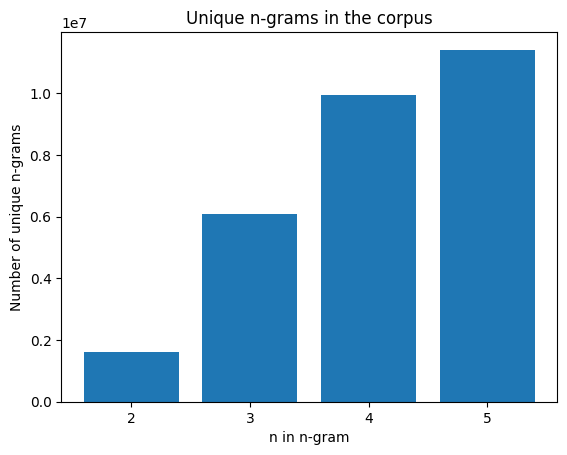

In [5]:
print("Number of unique n-grams:")
ngram_counts = {
    n: sum(len(value) 
    for value in grams.values()) for n, grams in ngrams.items()
}
for n in range(2, MAX_N + 1):
    count = ngram_counts[n]
    print(f"  {n}-grams: {count} (out of {len(tokens)**n:.2E} possible n-grams, 1 in {len(tokens)**n / count:.2E})")

import matplotlib.pyplot as plt
plt.bar(ngram_counts.keys(), ngram_counts.values())
plt.xlabel("n in n-gram")
plt.ylabel("Number of unique n-grams")
plt.title("Unique n-grams in the corpus")
plt.xticks(range(2, MAX_N + 1))
plt.show()